# H&M Dataset Quick Look

#### Library import and settings

In [98]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configures pandas to display more columns without wrapping
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_colwidth', None)  # Don't truncate content
pd.set_option('display.width', None)  # Use full width
pd.set_option('display.max_rows', 100)  # Show more rows if needed
pd.set_option('display.max_colwidth', 50) # Shows only first 50 characters

In [21]:
#Loads the data
customers = pd.read_csv('../data/raw/customers.csv')
articles = pd.read_csv('../data/raw/articles.csv')

#Peeks at first 100k rows
transactions = pd.read_csv('../data/raw/transactions_train.csv', nrows=100000)

## Data Overview

In [22]:
print("Customers shape:", customers.shape)
print("Articles shape:", articles.shape)
print("Transactions sample shape:", transactions.shape)

Customers shape: (1371980, 7)
Articles shape: (105542, 25)
Transactions sample shape: (100000, 5)


##### Heads

In [38]:
# Looks at the first few rows
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [40]:
articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,3,Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,1,Dusty Light,9,White,1676,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,4,Dark,5,Black,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,3,Light,9,White,1339,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [58]:
articles.head(0).T # Just the column names for ease of use

""
article_id
product_code
prod_name
product_type_no
product_type_name
product_group_name
graphical_appearance_no
graphical_appearance_name
colour_group_code
colour_group_name


In [25]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699338c5570910a014cc2,685687004,0.016932,2


## Customer Dataset Exploration


In [43]:
print(f"Total customers: {len(customers):,}")

Total customers: 1,371,980


In [158]:
print("\nMissing Values:")
customers.isnull().sum()


Missing Values:


customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
fashion_news                   0
dtype: int64

While there are some missing values for **club_member_status, fashion_news_frequency and age** the amount of missing values for FN and Active are likely indicators of the fact that those members don't have a subscribtion active

In [60]:
customers['age'].describe().round()

count    1356119.0
mean          36.0
std           14.0
min           16.0
25%           24.0
50%           32.0
75%           49.0
max           99.0
Name: age, dtype: float64

Difference between number of customers and number of ages implies that **some customers are missing age data**.  
**Average Age is 36**.  
**Median Age is 32**.  
this implies **right skew** of the age distribution

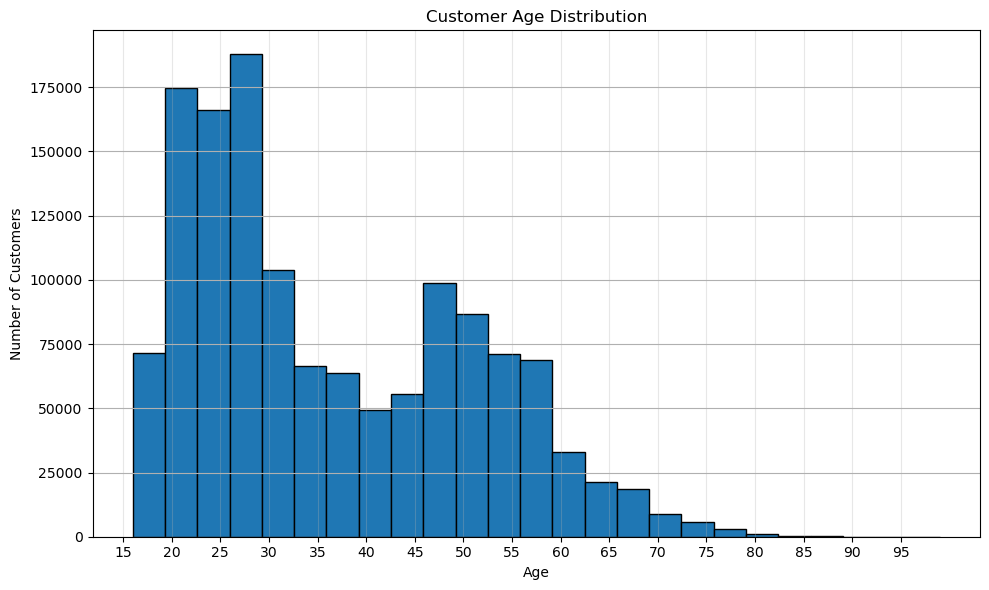

In [126]:
plt.figure(figsize=(10, 6))
customers['age'].hist(bins=25, edgecolor='black')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.xticks(range(15, 100, 5))
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [128]:
from sklearn.mixture import GaussianMixture

# Fit a Gaussian Mixture Model to find peaks
ages = customers['age'].dropna().values.reshape(-1, 1)
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(ages)

print("Detected peaks at ages:")
print(f"Peak 1: {gmm.means_[0][0]:.1f}")
print(f"Peak 2: {gmm.means_[1][0]:.1f}")
print(f"Weights: {gmm.weights_}")

Detected peaks at ages:
Peak 1: 49.6
Peak 2: 25.2
Weights: [0.4580488 0.5419512]


In [138]:
# Let's dig deeper into age segments
age_segments = pd.cut(customers['age'], 
                      bins=[0, 25, 35, 45, 55, 100], 
                      labels=['≤25', '26-35', 
                              '36-45', '46-55', 
                              '55+'])

print("Customer Age Segments:")
print(age_segments.value_counts(normalize=True).round(4) * 100)

Customer Age Segments:
age
≤25      30.39
26-35    26.41
46-55    18.92
36-45    12.45
55+      11.83
Name: proportion, dtype: float64


In [69]:
print("Fashion News Subscribers:")
customers['FN'].value_counts()
print(f"\n{(customers['FN'] == 1).sum() / len(customers) * 100:.1f}% subscribe to fashion news")

Fashion News Subscribers:

34.8% subscribe to fashion news


In [112]:
customers['fashion_news'] = customers['FN'].fillna(0)  # NaN = No subscription
print("Corrected Fashion News Distribution:")
print(customers['fashion_news'].value_counts())
print(f"Subscription rate: {customers['fashion_news'].mean()*100:.1f}%")

# Verify our assumption
print("\nOriginal FN column:")
print(customers['FN'].value_counts(dropna=False))

Corrected Fashion News Distribution:
fashion_news
0.0    895050
1.0    476930
Name: count, dtype: int64
Subscription rate: 34.8%

Original FN column:
FN
NaN    895050
1.0    476930
Name: count, dtype: int64


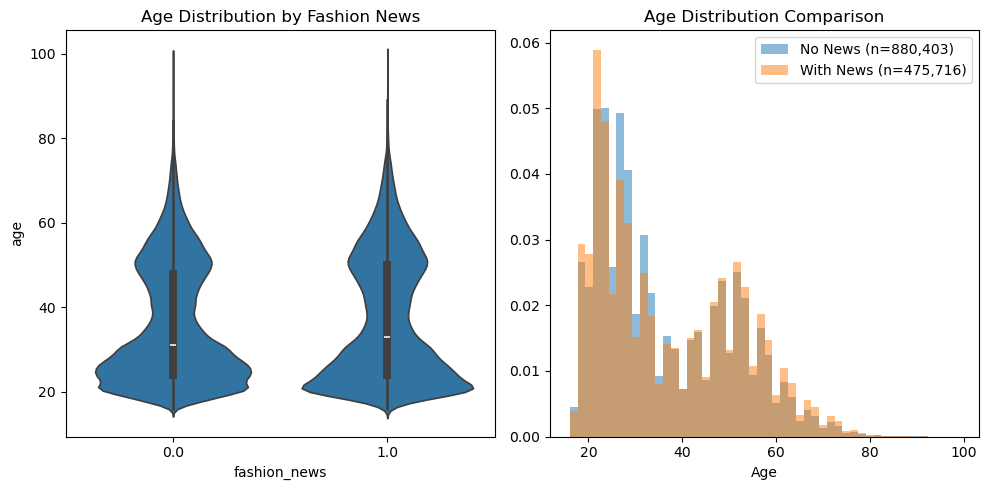


No subscription: Mean age = 36.0, Median = 31.0
With subscription: Mean age = 37.0, Median = 33.0


In [124]:
# Age vs Fashion News
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Violin plot
sns.violinplot(data=customers, x='fashion_news', y='age', ax=axes[0])
axes[0].set_title('Age Distribution by Fashion News')

# Histogram overlay
no_news = customers[customers['fashion_news'] == 0]['age'].dropna()
yes_news = customers[customers['fashion_news'] == 1]['age'].dropna()
axes[1].hist(no_news, bins=50, alpha=0.5, label=f'No News (n={len(no_news):,})', density=True)
axes[1].hist(yes_news, bins=50, alpha=0.5, label=f'With News (n={len(yes_news):,})', density=True)
axes[1].set_title('Age Distribution Comparison')
axes[1].legend()
axes[1].set_xlabel('Age')

plt.tight_layout()
plt.show()

# Statistics
print(f"\nNo subscription: Mean age = {no_news.mean():.1f}, Median = {no_news.median():.1f}")
print(f"With subscription: Mean age = {yes_news.mean():.1f}, Median = {yes_news.median():.1f}")

In [77]:
print("\nClub Member Status:")
customers['club_member_status'].value_counts()


Club Member Status:


club_member_status
ACTIVE        1272491
PRE-CREATE      92960
LEFT CLUB         467
Name: count, dtype: int64

In [154]:
# Process the entire dataset in chunks for this specific analysis
chunk_size = 1_000_000
weekday_counts = {}
weekend_counts = {'weekday': 0, 'weekend': 0}
row_count = 0

for chunk in pd.read_csv('../data/raw/transactions_train.csv', 
                         parse_dates=['t_dat'],
                         chunksize=chunk_size):
    # Process each chunk
    chunk['weekday'] = chunk['t_dat'].dt.day_name()
    
    # Accumulate counts
    for day, count in chunk['weekday'].value_counts().items():
        weekday_counts[day] = weekday_counts.get(day, 0) + count
    
    # Weekend analysis
    weekend_days = ['Saturday', 'Sunday']
    is_weekend = chunk['weekday'].isin(weekend_days)
    weekend_counts['weekend'] += is_weekend.sum()
    weekend_counts['weekday'] += (~is_weekend).sum()

    # Update row count - use len(chunk) to get number of rows
    row_count += len(chunk)
    print(f"Processed {row_count:,} rows...")

# Display results
print("\nPurchases by day of week:")
for day in ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']:
    if day in weekday_counts:
        print(f"{day}: {weekday_counts[day]:,}")

total = weekend_counts['weekday'] + weekend_counts['weekend']
print(f"\nWeekday purchases: {weekend_counts['weekday']:,}")
print(f"Weekend purchases: {weekend_counts['weekend']:,}")
print(f"Weekend percentage: {weekend_counts['weekend'] / total * 100:.1f}%")

Processed 1,000,000 rows...
Processed 2,000,000 rows...
Processed 3,000,000 rows...
Processed 4,000,000 rows...
Processed 5,000,000 rows...
Processed 6,000,000 rows...
Processed 7,000,000 rows...
Processed 8,000,000 rows...
Processed 9,000,000 rows...
Processed 10,000,000 rows...
Processed 11,000,000 rows...
Processed 12,000,000 rows...
Processed 13,000,000 rows...
Processed 14,000,000 rows...
Processed 15,000,000 rows...
Processed 16,000,000 rows...
Processed 17,000,000 rows...
Processed 18,000,000 rows...
Processed 19,000,000 rows...
Processed 20,000,000 rows...
Processed 21,000,000 rows...
Processed 22,000,000 rows...
Processed 23,000,000 rows...
Processed 24,000,000 rows...
Processed 25,000,000 rows...
Processed 26,000,000 rows...
Processed 27,000,000 rows...
Processed 28,000,000 rows...
Processed 29,000,000 rows...
Processed 30,000,000 rows...
Processed 31,000,000 rows...
Processed 31,788,324 rows...

Purchases by day of week:
Monday: 4,054,054
Tuesday: 4,198,630
Wednesday: 4,842,

In [161]:
from datetime import datetime

# Initialize aggregators for each metric
customer_data = {}
chunk_size = 1_000_000

print("Processing customer metrics in chunks...")
for i, chunk in enumerate(pd.read_csv('../data/raw/transactions_train.csv', 
                                       parse_dates=['t_dat'],
                                       chunksize=chunk_size)):
    
    # Calculate metrics for this chunk
    chunk_metrics = chunk.groupby('customer_id').agg({
        'price': ['sum', 'mean', 'count'],
        't_dat': ['min', 'max']
    })
    
    # Merge with existing customer data
    for customer_id in chunk_metrics.index:
        if customer_id not in customer_data:
            # First time seeing this customer
            customer_data[customer_id] = {
                'total_spent': chunk_metrics.loc[customer_id, ('price', 'sum')],
                'transaction_count': chunk_metrics.loc[customer_id, ('price', 'count')],
                'sum_for_mean': chunk_metrics.loc[customer_id, ('price', 'sum')],  # For recalculating mean
                'first_purchase': chunk_metrics.loc[customer_id, ('t_dat', 'min')],
                'last_purchase': chunk_metrics.loc[customer_id, ('t_dat', 'max')]
            }
        else:
            # Update existing customer data
            customer_data[customer_id]['total_spent'] += chunk_metrics.loc[customer_id, ('price', 'sum')]
            customer_data[customer_id]['transaction_count'] += chunk_metrics.loc[customer_id, ('price', 'count')]
            customer_data[customer_id]['sum_for_mean'] += chunk_metrics.loc[customer_id, ('price', 'sum')]
            customer_data[customer_id]['first_purchase'] = min(
                customer_data[customer_id]['first_purchase'],
                chunk_metrics.loc[customer_id, ('t_dat', 'min')]
            )
            customer_data[customer_id]['last_purchase'] = max(
                customer_data[customer_id]['last_purchase'],
                chunk_metrics.loc[customer_id, ('t_dat', 'max')]
            )
    
    print(f"Processed chunk {i+1}: {len(customer_data):,} unique customers so far")

# Convert to DataFrame
customer_metrics = pd.DataFrame.from_dict(customer_data, orient='index')
customer_metrics['avg_purchase_value'] = customer_metrics['sum_for_mean'] / customer_metrics['transaction_count']
customer_metrics['customer_lifetime_days'] = (customer_metrics['last_purchase'] - customer_metrics['first_purchase']).dt.days
customer_metrics.drop('sum_for_mean', axis=1, inplace=True)

print(f"\nFinal customer metrics: {len(customer_metrics):,} customers")

Processing customer metrics in chunks...
Processed chunk 1: 214,936 unique customers so far
Processed chunk 2: 353,916 unique customers so far
Processed chunk 3: 465,123 unique customers so far
Processed chunk 4: 555,030 unique customers so far
Processed chunk 5: 614,160 unique customers so far
Processed chunk 6: 666,750 unique customers so far
Processed chunk 7: 723,259 unique customers so far
Processed chunk 8: 762,675 unique customers so far
Processed chunk 9: 797,533 unique customers so far
Processed chunk 10: 829,742 unique customers so far
Processed chunk 11: 861,102 unique customers so far
Processed chunk 12: 889,809 unique customers so far
Processed chunk 13: 916,098 unique customers so far
Processed chunk 14: 940,353 unique customers so far
Processed chunk 15: 963,678 unique customers so far
Processed chunk 16: 985,843 unique customers so far
Processed chunk 17: 1,010,795 unique customers so far
Processed chunk 18: 1,035,447 unique customers so far
Processed chunk 19: 1,063,39

In [169]:
import pandas as pd
import time
import gc  # garbage collection to free memory

def fast_customer_metrics_no_deps():
    """Fast version using only pandas - no extra libraries needed"""
    
    chunk_size = 3_000_000  # Larger chunks since we're optimizing
    start_time = time.time()
    
    print("Processing customer metrics (optimized pandas)...")
    
    # Read ALL chunks first and aggregate each
    chunk_aggregates = []
    total_rows = 0
    
    for i, chunk in enumerate(pd.read_csv('../data/raw/transactions_train.csv',
                                           parse_dates=['t_dat'],
                                           chunksize=chunk_size)):
        
        # Aggregate this chunk
        chunk_agg = chunk.groupby('customer_id', as_index=False).agg({
            'price': ['sum', 'count'],
            't_dat': ['min', 'max']
        })
        
        # Flatten columns for easier merge
        chunk_agg.columns = ['customer_id', 'total_spent', 'trans_count', 'first_date', 'last_date']
        chunk_aggregates.append(chunk_agg)
        
        total_rows += len(chunk)
        elapsed = time.time() - start_time
        
        print(f"Chunk {i+1}: Processed {total_rows:,} rows in {elapsed:.1f}s "
              f"({total_rows/elapsed:,.0f} rows/sec)")
        
        # Free memory
        del chunk
        gc.collect()
    
    # Combine all chunk aggregates
    print("\n📊 Combining all chunks...")
    combined = pd.concat(chunk_aggregates, ignore_index=True)
    
    # Final aggregation (customers might appear in multiple chunks)
    print("📈 Final aggregation...")
    customer_metrics = combined.groupby('customer_id').agg({
        'total_spent': 'sum',
        'trans_count': 'sum', 
        'first_date': 'min',
        'last_date': 'max'
    }).reset_index()
    
    # Calculate derived fields
    customer_metrics['avg_purchase_value'] = customer_metrics['total_spent'] / customer_metrics['trans_count']
    customer_metrics['lifetime_days'] = (customer_metrics['last_date'] - customer_metrics['first_date']).dt.days
    
    total_time = time.time() - start_time
    print(f"\n✅ Complete! {len(customer_metrics):,} customers in {total_time:.1f} seconds")
    print(f"Average speed: {31_000_000/total_time:,.0f} rows/second")
    
    return customer_metrics

# Run it!
customer_metrics = fast_customer_metrics_no_deps()

# Save immediately so you don't have to rerun!
customer_metrics.to_csv('../data/processed/customer_metrics.csv', index=False)
print("💾 Saved to ../data/processed/customer_metrics.csv")

Processing customer metrics (optimized pandas)...
Chunk 1: Processed 3,000,000 rows in 3.6s (837,165 rows/sec)
Chunk 2: Processed 6,000,000 rows in 10.4s (576,543 rows/sec)
Chunk 3: Processed 9,000,000 rows in 16.1s (560,168 rows/sec)
Chunk 4: Processed 12,000,000 rows in 22.1s (542,898 rows/sec)
Chunk 5: Processed 15,000,000 rows in 27.8s (540,441 rows/sec)
Chunk 6: Processed 18,000,000 rows in 34.0s (528,774 rows/sec)
Chunk 7: Processed 21,000,000 rows in 40.4s (519,870 rows/sec)
Chunk 8: Processed 24,000,000 rows in 46.3s (518,412 rows/sec)
Chunk 9: Processed 27,000,000 rows in 52.3s (515,935 rows/sec)
Chunk 10: Processed 30,000,000 rows in 59.6s (503,708 rows/sec)
Chunk 11: Processed 31,788,324 rows in 64.2s (495,198 rows/sec)

📊 Combining all chunks...
📈 Final aggregation...

✅ Complete! 1,362,281 customers in 71.0 seconds
Average speed: 436,608 rows/second
💾 Saved to ../data/processed/customer_metrics.csv
